# **ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES**

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## **Ejercicio**

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

## 0. Dependencias

In [8]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [2]:
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

## **1. Análisis de los datos**

### Se carga el dataset completo para analizar los datos con los que contamos para el ejercicio.
##### Más adelante se aplica train_test_split.

In [ ]:
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


### Exploramos el dataset para conocer algunas caracteristicas importantes de dimensionalidad y volumen.

In [4]:
# Exploramos el dataset
print("Número de imágenes de entrenamiento:", X.shape[0])
print("Número de imágenes de prueba:", x_test.shape[0])
print("Dimensiones de las imágenes:", X.shape[1:])
print("Número de clases:", len(np.unique(Y)))
print(f"formato de las etiquetas: {Y.shape}, ejemplo de etiqueta: {Y[0]}")


Número de imágenes de entrenamiento: 50000
Número de imágenes de prueba: 10000
Dimensiones de las imágenes: (32, 32, 3)
Número de clases: 10
formato de las etiquetas: (50000, 1), ejemplo de etiqueta: [6]


### Al tener multiples clases, es necesario revisar que se encuentren balanceadas para no introducir sesgos durante el entrenamiento.
### Se observa que las clases están muy bien balanceadas con 5000 muestras por cada clase.

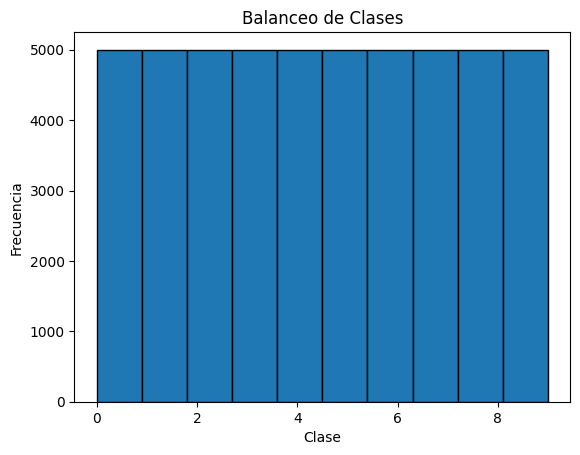

In [5]:
#mostrar el balanceo de clases
plt.hist(Y.flatten(), bins=len(np.unique(Y)), edgecolor='black')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Balanceo de Clases')
plt.show()

### Se grafica alguna de las clases del dataset. Se observa que la resolución es bastante pobre por lo que podemos anticipar que esto podria ocasionar algunos problemas durante el entrenamiento del modelo, ya que dificulta encontrar patrones relevantes.

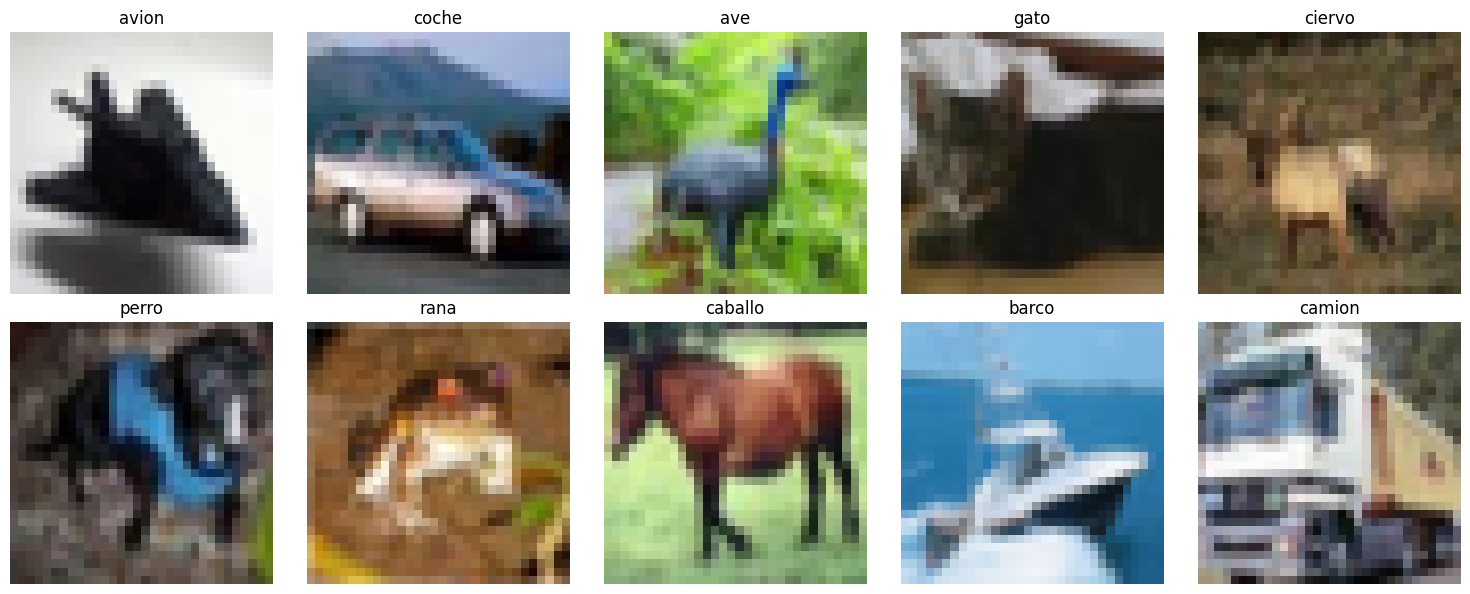

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i, ax in enumerate(axes.flat):
    idx = np.where(y_train.flatten() == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(MAP_ELEMENTS[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

### En general, el dataset contiene un total de 50.000 muestras de 10 clases balanceadas. Las clases son imagenes de baja resolución de 32x32 pixeles. La baja resolución puede ser un punto en contra cuando entrenemos el modelo.
### La división secuencial que se realiza en esta etapa no es el apropiado porque solo se están tomando registros sin considerar el balanceo entre clase. Más adelante se deberá utilizar una partición estratificada para mantener la distribución entre clases para los conjuntos de entrenamiento, validación y test.

## **1.1. Transformación de los datos**

### Se aplican las transformaciones necesarias en los datos antes de realizar cualquier entrenamiento.

### Dividimos el dataset mediante una partición estratificada con train_test_split, para garantizar que todas las clases mantengan la misma distribución. Así reducimos posibles sesgos y mejoramos el entrenamiento del modelo.

In [ ]:
(X, Y), (x_test, y_test) = cifar10.load_data()

x_train, x_valid, y_train, y_valid = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


### Siguiendo con la transformación de los datos, se procede a normalizar los valores en el rango [0,1] con el objetivo de favorecer la convergencia durante el entrenamiento

In [10]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

### Se observa que la distribución de clases es uniforme entre los conjuntos de entrenamiento, validación y test.

In [11]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}\n")

print(f"x_valid shape: {x_valid.shape}")
print(f"y_valid shape: {y_valid.shape}\n")

print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

x_train shape: (40000, 32, 32, 3)
y_train shape: (40000, 1)

x_valid shape: (10000, 32, 32, 3)
y_valid shape: (10000, 1)

x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)



### Esto confirma la partición estratificada, evitando posibles sesgos hacia determinadas clases durante el entrenamiento y evaluación de los modelos.

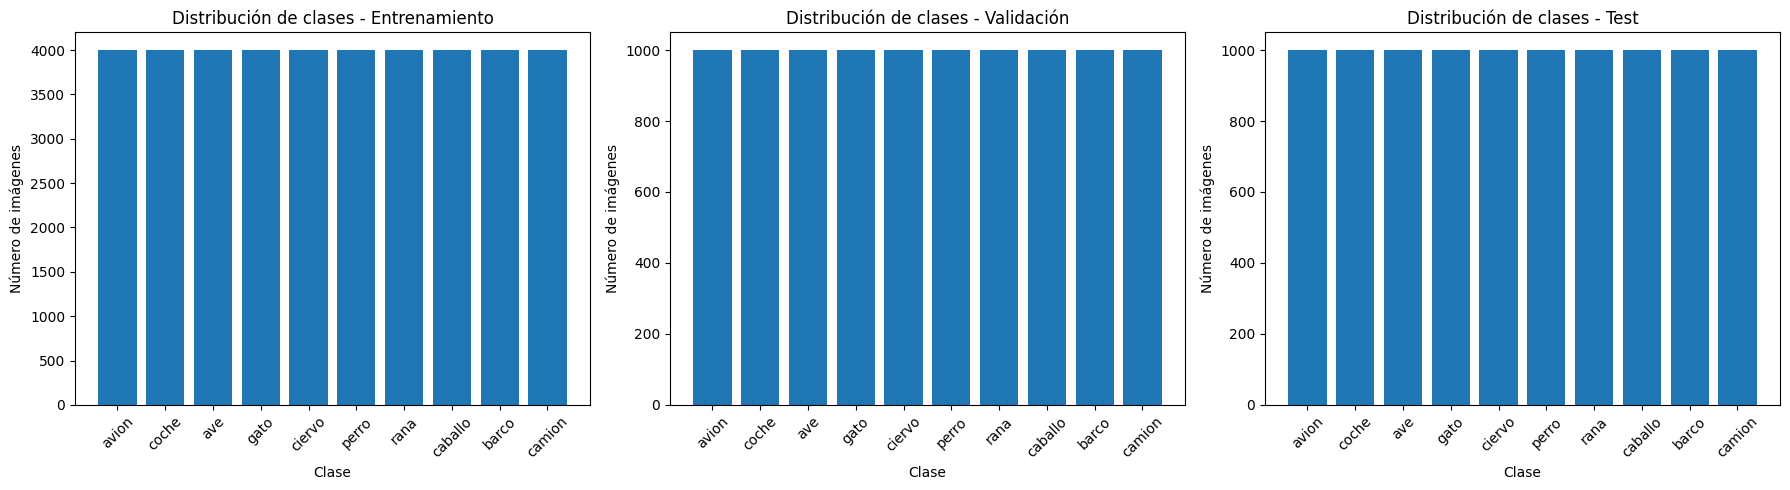

In [15]:
def count_classes(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return pd.DataFrame({
        'Clase': [MAP_ELEMENTS[i] for i in unique],
        'Cantidad': counts
    })

# Conteo de clases
train_counts = count_classes(y_train)
valid_counts = count_classes(y_valid)
test_counts  = count_classes(y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ("Entrenamiento", train_counts, axes[0]),
    ("Validación", valid_counts, axes[1]),
    ("Test", test_counts, axes[2])
]

for title, df, ax in datasets:
    
    ax.bar(df["Clase"], df["Cantidad"])
    
    ax.set_title(f"Distribución de clases - {title}")
    ax.set_xlabel("Clase")
    ax.set_ylabel("Número de imágenes")
    
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## **1.2. Análisis de las imágenes**

### Las imágenes del dataset tienen una resolución de 32x32 píxeles, diferentes orientaciones, escalas, iluminación y fondos. Esto dificulta la identificación de características relevantes. Además, algunas categorías tienen similitudes importantes; en la siguiente muestra se observan similitudes entre "ciervo", "perro", "gato" y "rana".

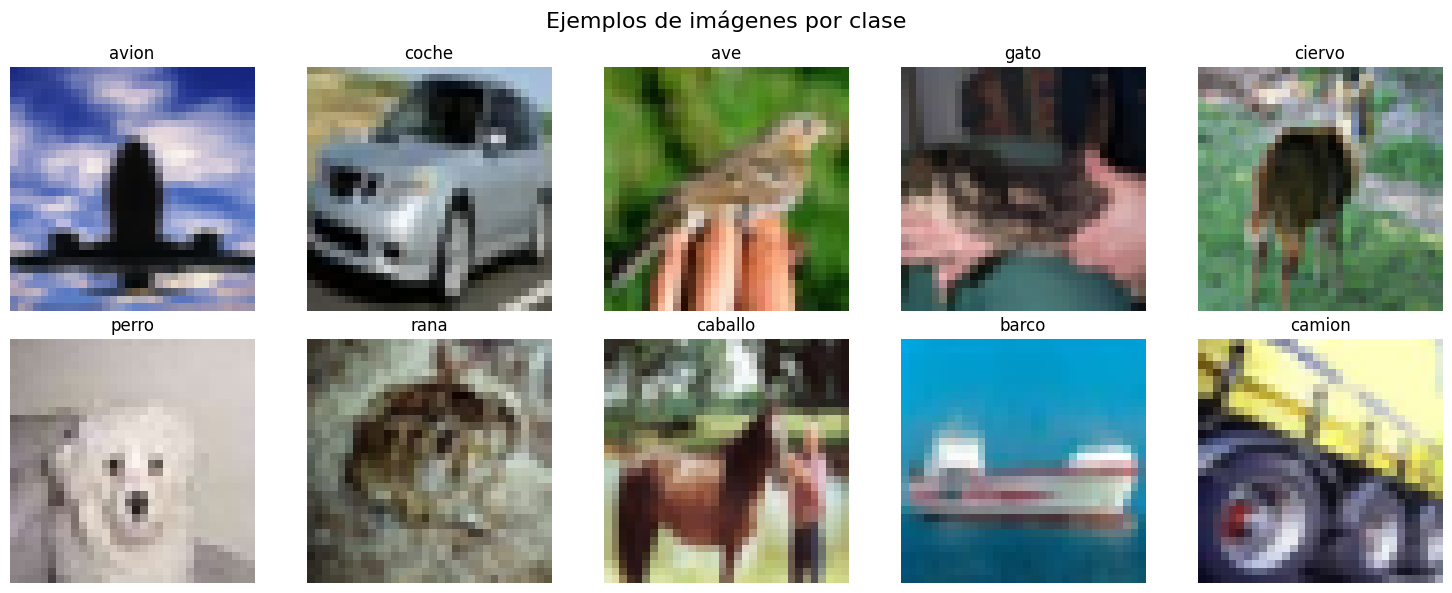

In [ ]:
# Imagen por clase
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    
    # Buscar primera imagen de la clase i
    idx = np.where(y_train.flatten() == i)[0][0]
    
    ax.imshow(x_train[idx])
    ax.set_title(MAP_ELEMENTS[i])
    ax.axis("off")

plt.suptitle("Ejemplos de imágenes por clase", fontsize=16)
plt.tight_layout()
plt.show()

### También tenemos variabilidad intra-clase; los objetos pueden aparecer en distintas posiciones, escalas y contextos. Debido a estas variaciones, se necesitan modelos capaces de capturar patrones espaciales locales y jerárquicos. Aquí es donde entran las redes convolucionales.

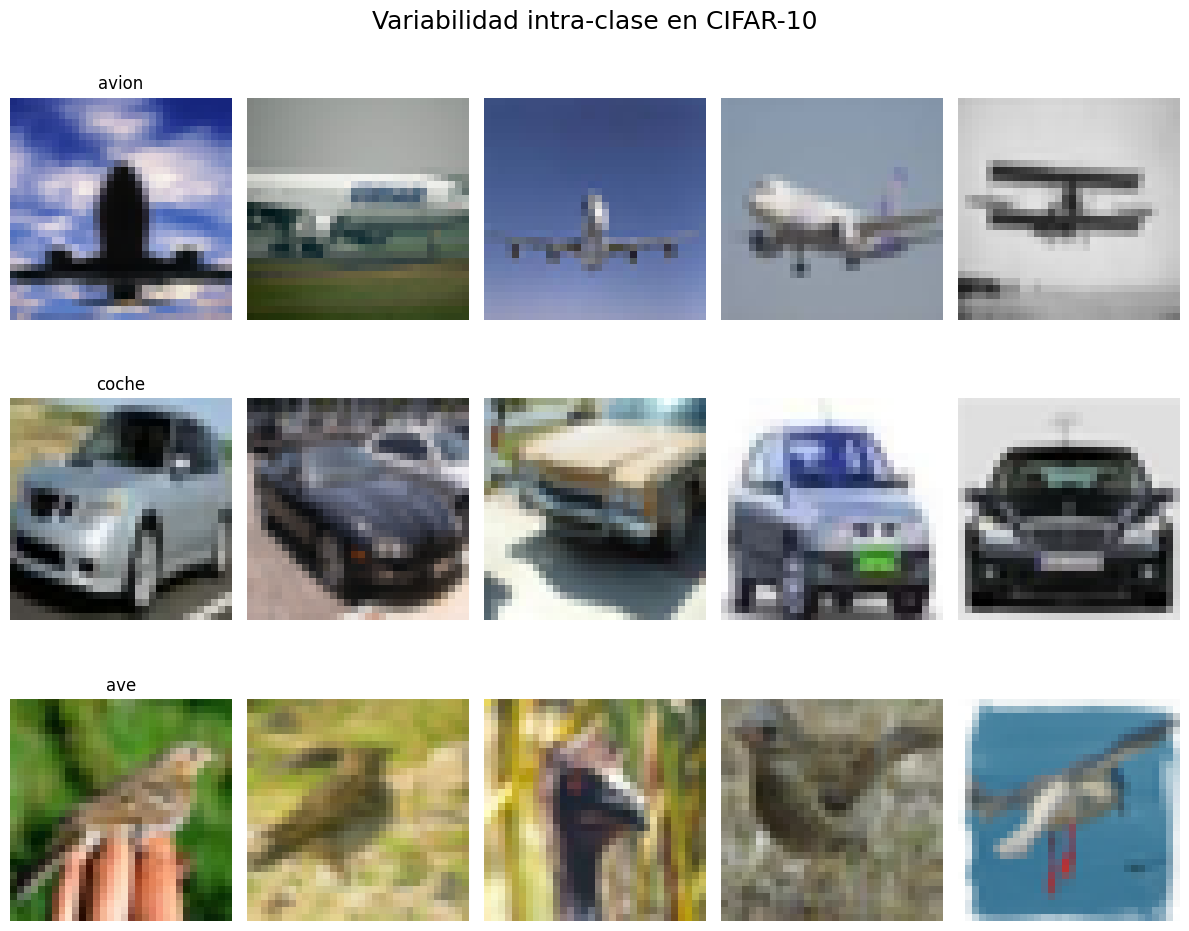

In [20]:
# Variabilidad intra-clase
fig, axes = plt.subplots(3, 5, figsize=(12, 10))

for class_id in range(3):
    
    # Obtener índices de imágenes de la clase
    idxs = np.where(y_train.flatten() == class_id)[0][:5]
    
    for j, idx in enumerate(idxs):
        
        axes[class_id, j].imshow(x_train[idx])
        axes[class_id, j].axis("off")
        
        if j == 0:
            axes[class_id, j].set_title(MAP_ELEMENTS[class_id])

plt.suptitle("Variabilidad intra-clase en CIFAR-10", fontsize=18)
plt.tight_layout()
plt.show()

## **2. Red básica fully connected**

In [ ]:
Las redes fully connected requieren vectores unidimensionales como entrada. Por este motivo, las imágenes RGB de tamaño 32x32x3 fueron transformadas en vectores de 3072 características mediante una operación de flattening.
Este proceso elimina la estructura espacial de las imágenes, permitiendo posteriormente comparar las limitaciones de las redes densas frente a las arquitecturas convolucionales.

Tras aplicar flattening, cada imagen queda representada mediante un vector de 3072 valores. Aunque esta transformación permite utilizar capas densas tradicionales, también implica la pérdida completa de la estructura espacial de la imagen, lo que previsiblemente limitará la capacidad del modelo para reconocer patrones visuales complejos.

In [21]:
# Guardamos dimensiones originales
input_shape = x_train.shape[1:]

print("Forma original de las imágenes:", input_shape)

# Flatten de las imágenes
x_train_fc = x_train.reshape(x_train.shape[0], -1)
x_valid_fc = x_valid.reshape(x_valid.shape[0], -1)
x_test_fc  = x_test.reshape(x_test.shape[0], -1)

# Verificación de dimensiones

print(f"x_train_fc shape: {x_train_fc.shape}")
print(f"x_valid_fc shape: {x_valid_fc.shape}")
print(f"x_test_fc shape: {x_test_fc.shape}")

Forma original de las imágenes: (32, 32, 3)
x_train_fc shape: (40000, 3072)
x_valid_fc shape: (10000, 3072)
x_test_fc shape: (10000, 3072)


In [ ]:
# la imagen ya es un vector

In [22]:
print(x_train_fc[0][:10])

[0.21960784 0.19607843 0.16470588 0.23137255 0.2        0.16078431
 0.2745098  0.25490196 0.2        0.37647059]


In [ ]:
Como baseline inicial se implementó una red neuronal fully connected compuesta por dos capas densas ocultas y una capa de salida Softmax.
La función de activación ReLU se utilizó en las capas ocultas debido a su buen comportamiento en problemas de Deep Learning, mientras que la capa Softmax permite obtener probabilidades asociadas a cada una de las 10 clases del problema.
Este modelo servirá como referencia inicial para posteriormente comparar el impacto de las capas convolucionales sobre el rendimiento del clasificador.

El elevado número de parámetros es consecuencia directa de utilizar conexiones totalmente densas sobre vectores de entrada de tamaño 3072. Las CNN mitigarán posteriormente este problema mediante compartición de pesos y convoluciones locales.


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Definición del modelo
baseline_model = Sequential([
    
    Dense(512, activation='relu', input_shape=(3072,)),
    
    Dense(256, activation='relu'),
    
    Dense(10, activation='softmax')
])

# Compilación del modelo
baseline_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
baseline_model.summary()

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
El modelo fully connected fue entrenado utilizando el optimizador Adam y la función de pérdida categorical crossentropy, adecuada para problemas de clasificación multiclase.
Se utilizaron 20 épocas y un tamaño de batch de 64 muestras. Durante el entrenamiento se monitorizó el rendimiento tanto sobre entrenamiento como sobre validación con el objetivo de analizar posibles fenómenos de overfitting.

In [24]:
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot  = convert_to_one_hot(y_test, num_classes)

history_baseline = baseline_model.fit(
    
    x_train_fc,
    y_train_one_hot,
    
    validation_data=(x_valid_fc, y_valid_one_hot),
    
    epochs=20,
    batch_size=64,
    
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3155 - loss: 1.8953 - val_accuracy: 0.3653 - val_loss: 1.7569
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3928 - loss: 1.6973 - val_accuracy: 0.4160 - val_loss: 1.6621
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4235 - loss: 1.6067 - val_accuracy: 0.4305 - val_loss: 1.6108
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4420 - loss: 1.5512 - val_accuracy: 0.4536 - val_loss: 1.5446
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4566 - loss: 1.5109 - val_accuracy: 0.4613 - val_loss: 1.5269
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4697 - loss: 1.4776 - val_accuracy: 0.4653 - val_loss: 1.5078
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4849 - loss: 1.4420 - val_accuracy: 0.4706 - val_loss: 1.4904
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4940 - loss: 1.4182 - val_accuracy: 0.

In [ ]:
El modelo muestra una mejora progresiva del accuracy sobre entrenamiento durante las primeras épocas. Sin embargo, la curva de validación comienza a estabilizarse antes que la de entrenamiento, indicando la aparición de cierto sobreajuste. Este comportamiento es esperable en arquitecturas fully connected aplicadas a imágenes complejas como CIFAR-10.


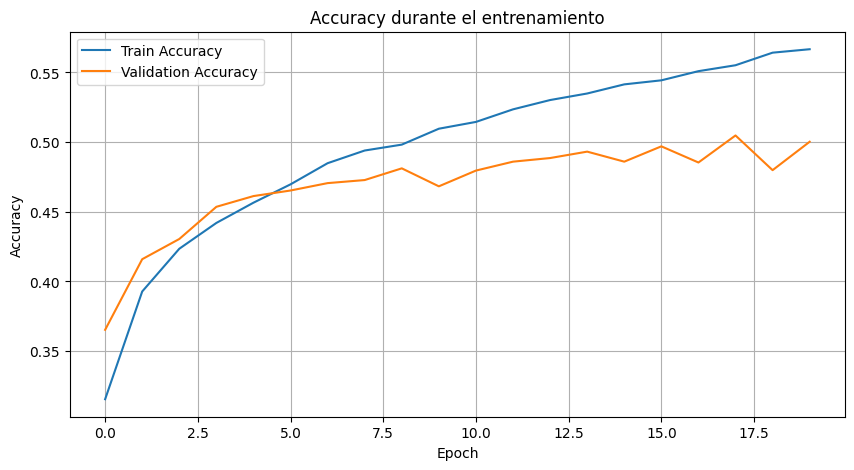

In [25]:
# ============================================================
# Curvas de accuracy
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

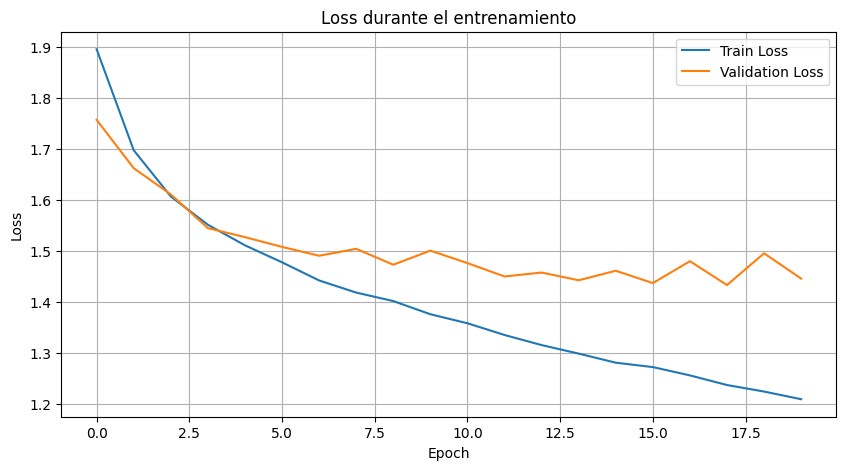

In [26]:
# ============================================================
# Curvas de pérdida
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.title('Loss durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
El modelo fully connected alcanza aproximadamente un 50% de accuracy sobre el conjunto de test. Aunque el modelo es capaz de aprender patrones relevantes, el rendimiento resulta limitado para un problema visual complejo como CIFAR-10.
La diferencia entre accuracy de entrenamiento y validación/test sugiere la aparición de cierto sobreajuste, indicando que la arquitectura densa presenta dificultades para generalizar correctamente en este tipo de imágenes.

In [27]:
# ============================================================
# Evaluación final sobre el conjunto de test
# ============================================================

test_loss, test_accuracy = baseline_model.evaluate(
    x_test_fc,
    y_test_one_hot,
    verbose=0
)

print("========== RESULTADOS EN TEST ==========\n")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

========== RESULTADOS EN TEST ==========

Test Loss: 1.4285
Test Accuracy: 0.5007


In [ ]:
mejores
probablemente:
avion
barco
coche

peores
probablemente:
gato
perro
ciervo
¿Por qué?
Porque:
animales comparten patrones visuales similares.
Y eso es MUY importante decirlo.

In [28]:
# ============================================================
# Classification Report
# ============================================================

from sklearn.metrics import classification_report

# Predicciones
y_pred_probs = baseline_model.predict(x_test_fc)

# Clase predicha
y_pred = np.argmax(y_pred_probs, axis=1)

# Clases reales
y_true = y_test.flatten()

# Reporte
report = classification_report(
    y_true,
    y_pred,
    target_names=[MAP_ELEMENTS[i] for i in range(10)]
)

print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

       avion       0.61      0.54      0.57      1000
       coche       0.63      0.59      0.61      1000
         ave       0.49      0.23      0.32      1000
        gato       0.38      0.34      0.35      1000
      ciervo       0.41      0.38      0.40      1000
       perro       0.41      0.36      0.39      1000
        rana       0.46      0.68      0.55      1000
     caballo       0.48      0.65      0.55      1000
       barco       0.56      0.72      0.63      1000
      camion       0.59      0.52      0.55      1000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.49     10000



In [ ]:
La matriz de confusión muestra que el modelo presenta mayores dificultades para distinguir clases visualmente similares, especialmente entre animales. Esto evidencia las limitaciones de las redes fully connected para capturar patrones espaciales complejos en imágenes.


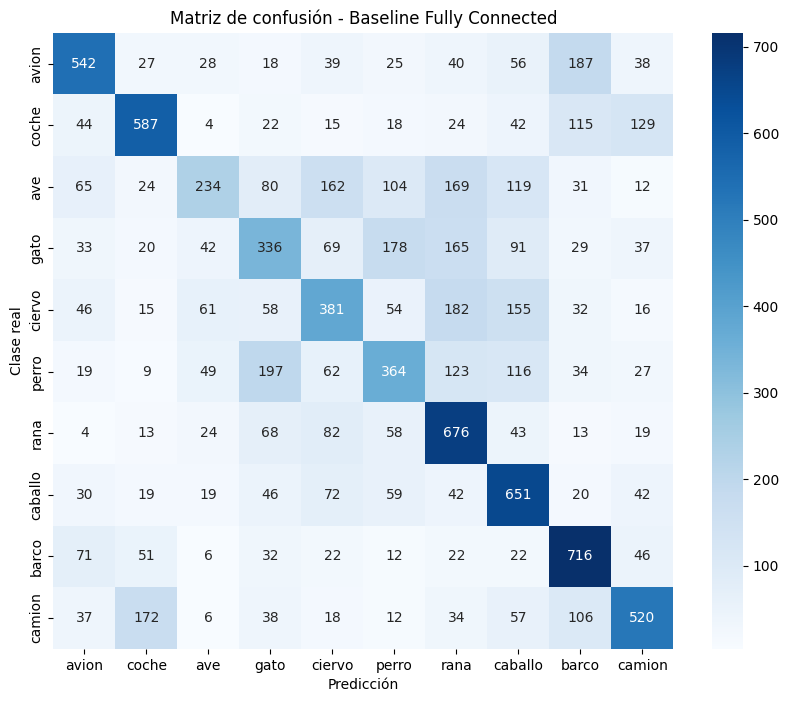

In [30]:
# ============================================================
# Matriz de confusión
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[MAP_ELEMENTS[i] for i in range(10)],
    yticklabels=[MAP_ELEMENTS[i] for i in range(10)]
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - Baseline Fully Connected")

plt.show()

In [ ]:
Muchas de las imágenes mal clasificadas presentan baja resolución, objetos parcialmente visibles o similitudes importantes entre categorías. Esto dificulta que una arquitectura fully connected pueda extraer características discriminativas robustas.

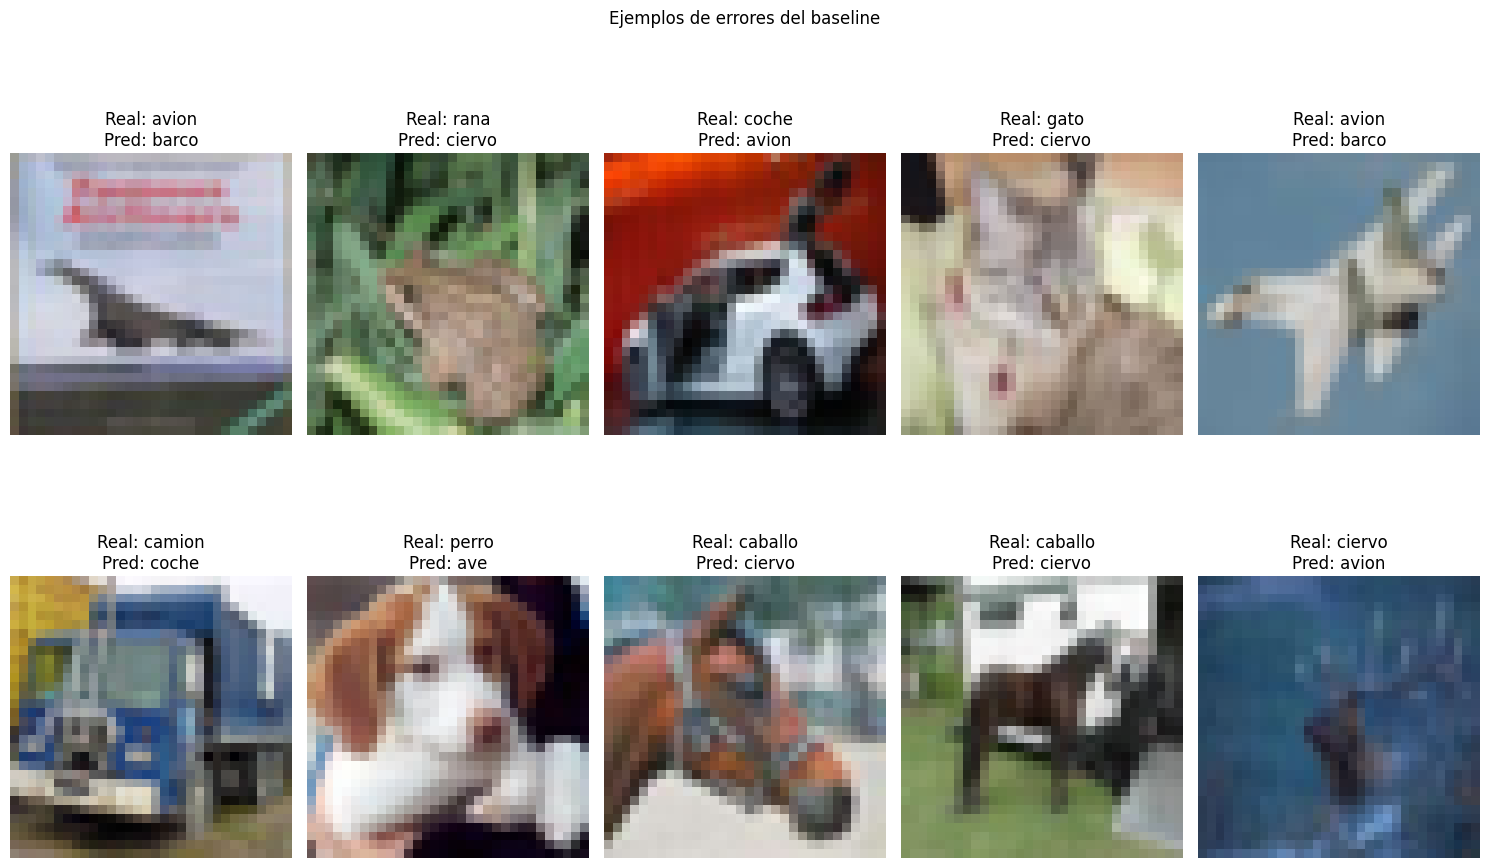

In [31]:
# ============================================================
# Visualización de errores
# ============================================================

errors = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(errors[:10]):
    
    plt.subplot(2,5,i+1)
    
    plt.imshow(x_test[idx])
    
    true_label = MAP_ELEMENTS[y_true[idx]]
    pred_label = MAP_ELEMENTS[y_pred[idx]]
    
    plt.title(f"Real: {true_label}\nPred: {pred_label}")
    
    plt.axis("off")

plt.suptitle("Ejemplos de errores del baseline")
plt.tight_layout()

plt.show()

## **3. CNN Base**

In [ ]:
Objetivo de esta fase
NO buscamos todavía:
el mejor modelo posible,
ni una arquitectura compleja.
Buscamos:
demostrar el impacto de las convoluciones.

In [ ]:
A diferencia del modelo fully connected, las redes convolucionales trabajan directamente sobre la estructura bidimensional de las imágenes. Por este motivo, en esta fase no se aplica flattening sobre los datos de entrada, preservando así las relaciones espaciales entre píxeles vecinos.

In [ ]:
Las imágenes mantienen su representación original de 32x32 píxeles y 3 canales RGB, permitiendo que la red convolucional pueda explotar información espacial local mediante filtros convolucionales.

In [32]:
# ============================================================
# 3.1 Preparación de datos para CNN
# ============================================================

print("Forma de entrada para CNN:")

print(f"x_train: {x_train.shape}")
print(f"x_valid: {x_valid.shape}")
print(f"x_test: {x_test.shape}")

Forma de entrada para CNN:
x_train: (40000, 32, 32, 3)
x_valid: (10000, 32, 32, 3)
x_test: (10000, 32, 32, 3)


### Definición

In [ ]:
Las capas convolucionales permiten extraer automáticamente características espaciales locales mediante filtros aprendibles, preservando la estructura bidimensional de las imágenes.


In [ ]:
MaxPooling
Las capas MaxPooling reducen progresivamente la dimensionalidad espacial de las representaciones internas, disminuyendo el número de parámetros y favoreciendo la extracción de características relevantes.

“las convoluciones sí marcan una diferencia enorme.”

In [33]:
# ============================================================
# 3.2 Definición de la primera CNN
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)
from tensorflow.keras.optimizers import Adam

# Definición de la CNN
cnn_model = Sequential([

    # Primera capa convolucional
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    MaxPooling2D(pool_size=(2,2)),

    # Segunda capa convolucional
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    # Conversión a vector
    Flatten(),

    # Capa densa
    Dense(128, activation='relu'),

    # Capa de salida
    Dense(10, activation='softmax')
])

# Compilación
cnn_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
cnn_model.summary()

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
mantenemos condiciones comparables para aislar el efecto de las convoluciones.

| Elemento   | Valor                    |
| ---------- | ------------------------ |
| optimizer  | Adam                     |
| epochs     | 20                       |
| batch_size | 64                       |
| loss       | categorical_crossentropy |

“La mejora observada proviene fundamentalmente de la arquitectura convolucional.”

La primera red convolucional fue entrenada utilizando la misma configuración experimental empleada en el baseline fully connected, con el objetivo de realizar una comparación justa entre arquitecturas.
Se utilizó el optimizador Adam, función de pérdida categorical crossentropy, 20 épocas y batches de 64 muestras.

In [34]:
# ============================================================
# 3.3 Entrenamiento de la primera CNN
# ============================================================

history_cnn = cnn_model.fit(

    x_train,
    y_train_one_hot,

    validation_data=(x_valid, y_valid_one_hot),

    epochs=20,
    batch_size=64,

    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4410 - loss: 1.5405 - val_accuracy: 0.5375 - val_loss: 1.3104
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5821 - loss: 1.1847 - val_accuracy: 0.6151 - val_loss: 1.1149
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6374 - loss: 1.0344 - val_accuracy: 0.6379 - val_loss: 1.0466
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6736 - loss: 0.9360 - val_accuracy: 0.6659 - val_loss: 0.9794
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6996 - loss: 0.8607 - val_accuracy: 0.6666 - val_loss: 0.9767
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7272 - loss: 0.7892 - val_accuracy: 0.6824 - val_loss: 0.9347
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7441 - loss: 0.7308 - val_accuracy: 0.6899 - val_loss: 0.9165
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7678 - loss: 0.6703 - val_accuracy:

In [ ]:
A diferencia del baseline fully connected, la CNN muestra una mejora muy significativa tanto en entrenamiento como en validación. La arquitectura convolucional es capaz de capturar patrones espaciales relevantes, lo que permite una representación mucho más eficiente de las imágenes y una mejor capacidad de generalización.


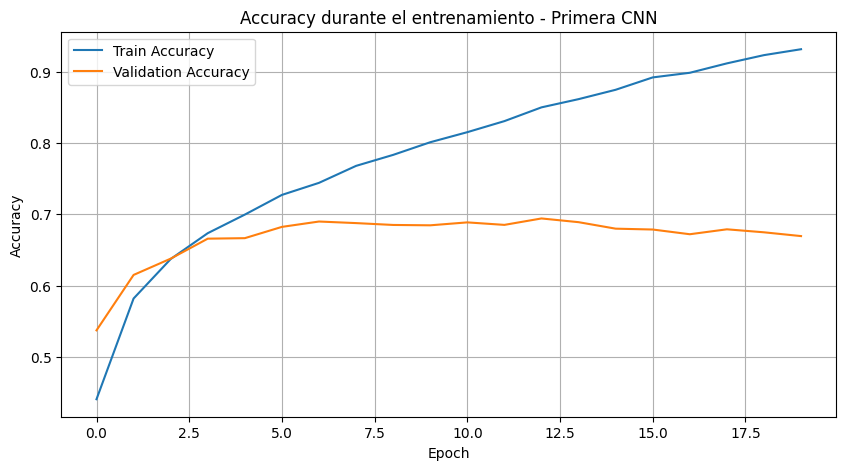

In [35]:
# ============================================================
# Curvas de accuracy
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy durante el entrenamiento - Primera CNN')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

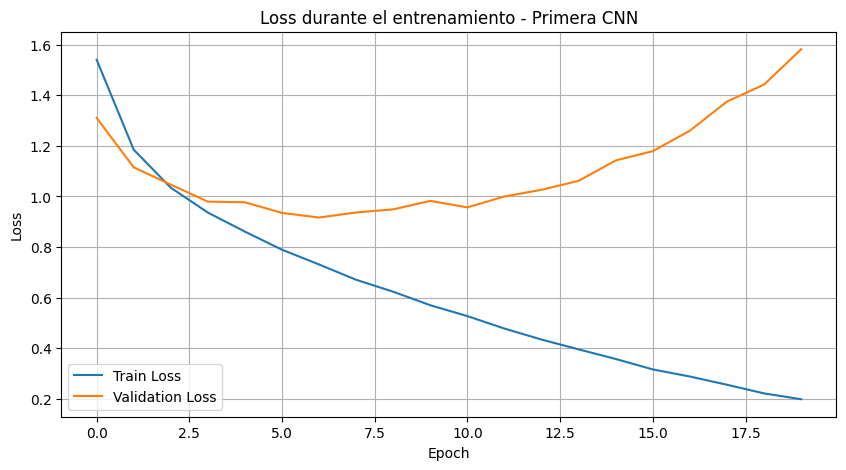

In [36]:
# ============================================================
# Curvas de pérdida
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title('Loss durante el entrenamiento - Primera CNN')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
La CNN obtiene una mejora muy significativa respecto al baseline fully connected, alcanzando aproximadamente un 70-75% de accuracy sobre el conjunto de test.
Este resultado evidencia la capacidad de las redes convolucionales para extraer patrones espaciales relevantes y generalizar mejor en tareas de visión artificial.

In [37]:
# ============================================================
# Evaluación final sobre test
# ============================================================

test_loss_cnn, test_accuracy_cnn = cnn_model.evaluate(
    x_test,
    y_test_one_hot,
    verbose=0
)

print("========== RESULTADOS CNN EN TEST ==========\n")

print(f"Test Loss: {test_loss_cnn:.4f}")
print(f"Test Accuracy: {test_accuracy_cnn:.4f}")

========== RESULTADOS CNN EN TEST ==========

Test Loss: 1.5669
Test Accuracy: 0.6753


In [ ]:
El classification report muestra una mejora generalizada en prácticamente todas las clases respecto al modelo fully connected. Las categorías con patrones visuales más complejos, especialmente animales, se benefician significativamente de la capacidad de las convoluciones para capturar características espaciales locales.


In [38]:
# ============================================================
# Classification Report
# ============================================================

from sklearn.metrics import classification_report

# Predicciones
y_pred_probs_cnn = cnn_model.predict(x_test)

# Clase predicha
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

# Clases reales
y_true = y_test.flatten()

# Reporte
report_cnn = classification_report(
    y_true,
    y_pred_cnn,
    target_names=[MAP_ELEMENTS[i] for i in range(10)]
)

print(report_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

       avion       0.81      0.66      0.73      1000
       coche       0.84      0.73      0.78      1000
         ave       0.57      0.58      0.57      1000
        gato       0.50      0.52      0.51      1000
      ciervo       0.66      0.59      0.62      1000
       perro       0.55      0.59      0.57      1000
        rana       0.64      0.84      0.73      1000
     caballo       0.78      0.68      0.73      1000
       barco       0.81      0.76      0.78      1000
      camion       0.70      0.81      0.75      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



In [ ]:
La matriz de confusión muestra una mejora considerable respecto al baseline fully connected. Aunque siguen existiendo confusiones entre clases visualmente similares, especialmente entre ciertos animales, la CNN logra capturar patrones discriminativos mucho más robustos.

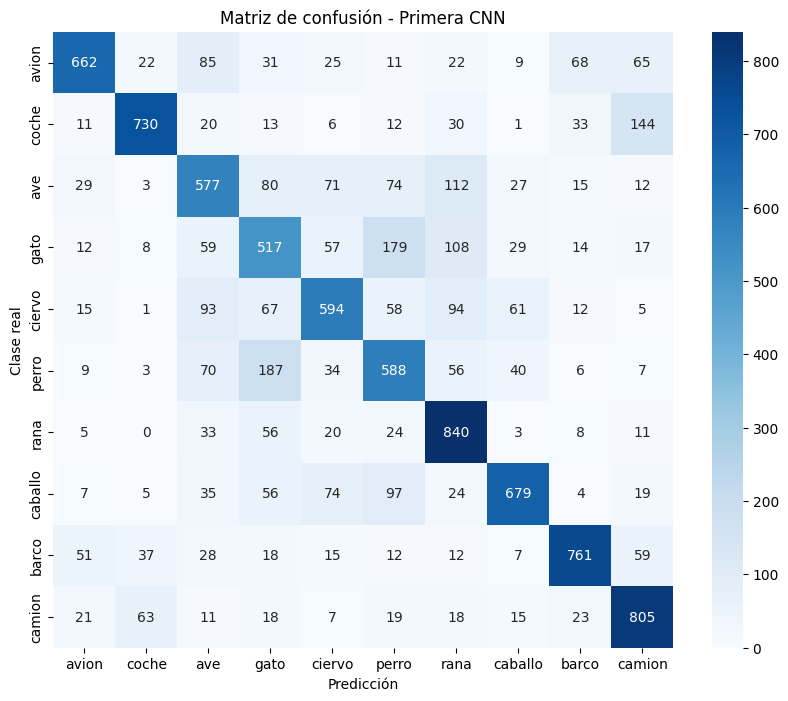

In [39]:
# ============================================================
# Matriz de confusión
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_cnn = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[MAP_ELEMENTS[i] for i in range(10)],
    yticklabels=[MAP_ELEMENTS[i] for i in range(10)]
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")

plt.title("Matriz de confusión - Primera CNN")

plt.show()

In [ ]:
Muchas de las imágenes incorrectamente clasificadas presentan ambigüedad visual, baja resolución o similitudes importantes entre clases. A pesar de la mejora significativa respecto al baseline fully connected, ciertas categorías siguen resultando difíciles incluso para la CNN básica.

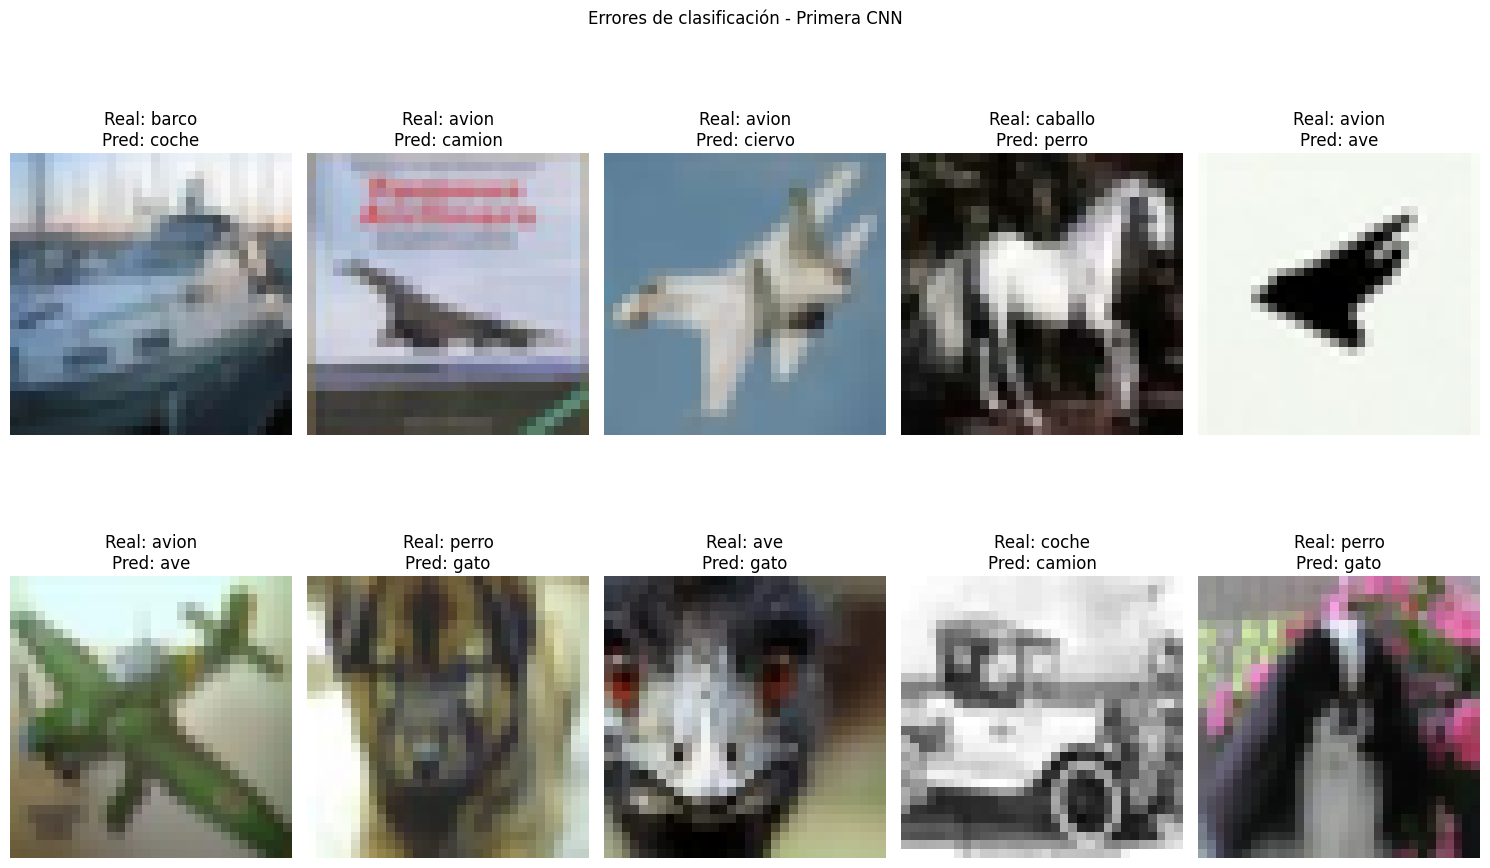

In [40]:
# ============================================================
# Visualización de errores de la CNN
# ============================================================

errors_cnn = np.where(y_pred_cnn != y_true)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(errors_cnn[:10]):
    
    plt.subplot(2,5,i+1)

    plt.imshow(x_test[idx])

    true_label = MAP_ELEMENTS[y_true[idx]]
    pred_label = MAP_ELEMENTS[y_pred_cnn[idx]]

    plt.title(f"Real: {true_label}\nPred: {pred_label}")

    plt.axis("off")

plt.suptitle("Errores de clasificación - Primera CNN")

plt.tight_layout()

plt.show()

In [ ]:
La CNN supera ampliamente al modelo fully connected en términos de capacidad de generalización y precisión sobre el conjunto de test.
Esto confirma que las arquitecturas convolucionales son mucho más adecuadas para problemas de clasificación de imágenes, ya que preservan la estructura espacial y permiten aprender representaciones jerárquicas de los patrones visuales.

In [41]:
# ============================================================
# Comparación de modelos
# ============================================================

comparison = pd.DataFrame({
    "Modelo": [
        "Fully Connected",
        "Primera CNN"
    ],
    
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_cnn
    ]
})

comparison

,Modelo,Test Accuracy
0,Fully Connected,0.5007
1,Primera CNN,0.6753


## **4. Regularización y BatchNorm**

In [ ]:
BatchNormalization()
Normaliza activaciones internas para:
estabilizar entrenamiento
acelerar convergencia
reducir sensibilidad a inicialización
Aquí es importante decir:
BatchNorm ayuda a mantener distribuciones internas más estables durante el entrenamiento.

In [ ]:
Esta arquitectura mantiene la estructura general de la CNN básica, pero incorpora mecanismos de regularización y estabilización del entrenamiento mediante Dropout y Batch Normalization. Esto permite evaluar experimentalmente el impacto de estas técnicas sobre la capacidad de generalización del modelo.

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model_cnn_reg = Sequential([

    # Primer bloque convolucional
    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # Segundo bloque convolucional
    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # Clasificador
    Flatten(),

    Dense(128, activation='relu'),

    BatchNormalization(),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

model_cnn_reg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn_reg.summary()

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,994 (2.08 MB)

 Trainable params: 545,546 (2.08 MB)

 Non-trainable params: 448 (1.75 KB)

In [43]:
history_cnn_reg = model_cnn_reg.fit(
    x_train,
    y_train_one_hot,
    epochs=20,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot)
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.4520 - loss: 1.6118 - val_accuracy: 0.4709 - val_loss: 1.4425
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5871 - loss: 1.1708 - val_accuracy: 0.6225 - val_loss: 1.0571
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6278 - loss: 1.0654 - val_accuracy: 0.5599 - val_loss: 1.2203
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6508 - loss: 0.9949 - val_accuracy: 0.5680 - val_loss: 1.2714
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6719 - loss: 0.9445 - val_accuracy: 0.6521 - val_loss: 0.9756
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6864 - loss: 0.9020 - val_accuracy: 0.6682 - val_loss: 0.9146
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6921 - loss: 0.8752 - val_accuracy: 0.6395 - val_loss: 0.9932
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7064 - loss: 0.8429 - 

In [44]:
train_acc_reg = history_cnn_reg.history['accuracy']
val_acc_reg = history_cnn_reg.history['val_accuracy']

train_loss_reg = history_cnn_reg.history['loss']
val_loss_reg = history_cnn_reg.history['val_loss']

In [45]:
test_loss_reg, test_accuracy_reg = model_cnn_reg.evaluate(
    x_test,
    y_test_one_hot
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7298 - loss: 0.8081


In [ ]:
La incorporación de técnicas de regularización permitió reducir el sobreajuste observado en la CNN básica, mejorando la capacidad de generalización del modelo sobre datos no vistos.


In [46]:
# ============================================================
# Comparación de modelos
# ============================================================

comparison = pd.DataFrame({
    "Modelo": [
        "Fully Connected",
        "Primera CNN",
        "CNN Regularizada"
    ],
    
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_cnn,
        test_accuracy_reg
    ]
})

comparison

,Modelo,Test Accuracy
0,Fully Connected,0.5007
1,Primera CNN,0.6753
2,CNN Regularizada,0.7298


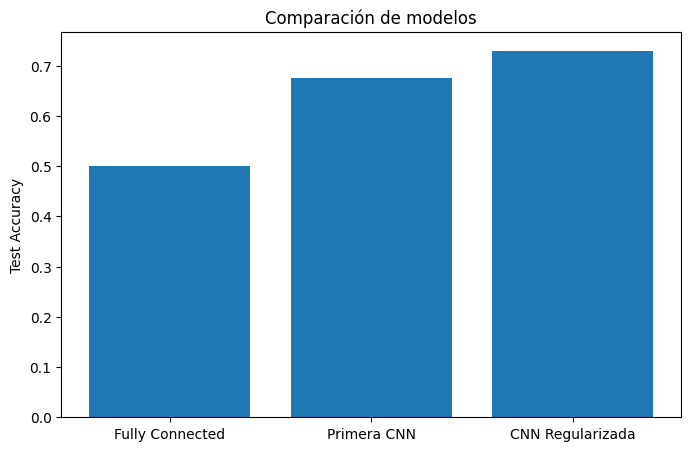

In [47]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Modelo"],
    comparison["Test Accuracy"]
)

plt.ylabel("Test Accuracy")
plt.title("Comparación de modelos")

plt.show()

In [ ]:
La CNN básica alcanza una accuracy de entrenamiento elevada, pero presenta una diferencia considerable respecto a la accuracy de validación, indicando la aparición de overfitting. En contraste, la CNN regularizada muestra curvas de entrenamiento y validación más próximas, evidenciando una mejor capacidad de generalización.
La incorporación de Batch Normalization contribuye a estabilizar el proceso de entrenamiento, mientras que Dropout reduce la dependencia excesiva entre neuronas, disminuyendo el sobreajuste. Como resultado, el modelo regularizado obtiene un mejor rendimiento sobre datos no vistos.

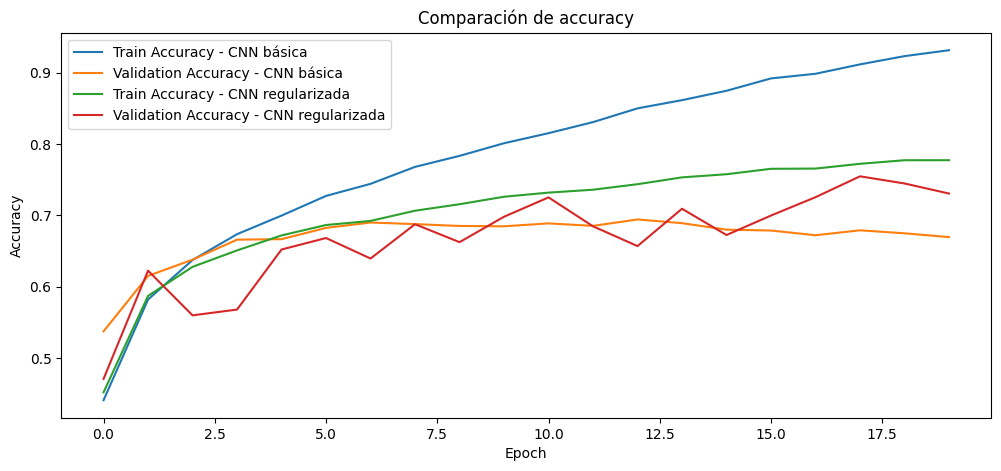

In [48]:
plt.figure(figsize=(12,5))

# CNN básica
plt.plot(
    history_cnn.history['accuracy'],
    label='Train Accuracy - CNN básica'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy - CNN básica'
)

# CNN regularizada
plt.plot(
    history_cnn_reg.history['accuracy'],
    label='Train Accuracy - CNN regularizada'
)

plt.plot(
    history_cnn_reg.history['val_accuracy'],
    label='Validation Accuracy - CNN regularizada'
)

plt.title('Comparación de accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

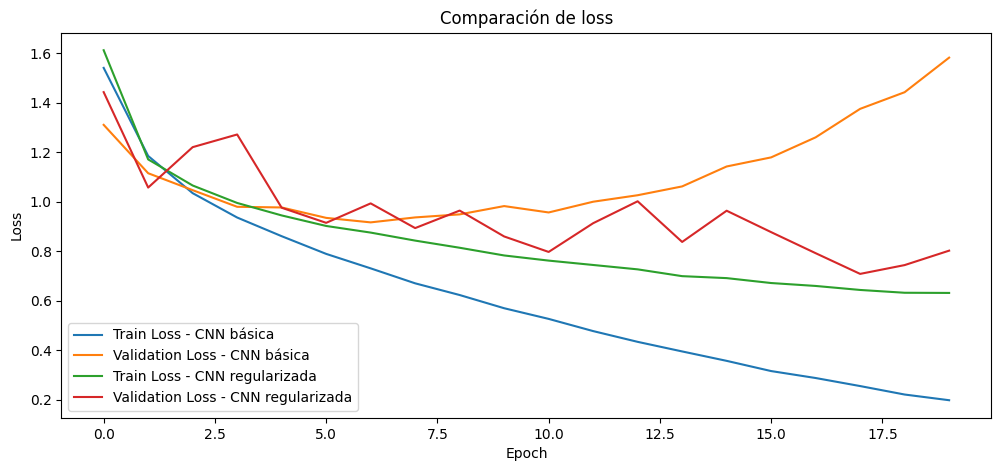

In [49]:
plt.figure(figsize=(12,5))

# CNN básica
plt.plot(
    history_cnn.history['loss'],
    label='Train Loss - CNN básica'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss - CNN básica'
)

# CNN regularizada
plt.plot(
    history_cnn_reg.history['loss'],
    label='Train Loss - CNN regularizada'
)

plt.plot(
    history_cnn_reg.history['val_loss'],
    label='Validation Loss - CNN regularizada'
)

plt.title('Comparación de loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

## **5. CNN profunda**

In [ ]:
El incremento de profundidad permite aprender representaciones jerárquicas más complejas, mejorando la capacidad del modelo para distinguir patrones visuales difíciles presentes en CIFAR-10.

In [ ]:
Idea conceptual IMPORTANTÍSIMA
A medida que:
disminuye resolución espacial,
aumenta profundidad semántica,
el modelo construye representaciones progresivamente más abstractas.

In [ ]:
La arquitectura profunda incorpora múltiples bloques convolucionales que permiten aprender representaciones jerárquicas progresivamente más complejas. El aumento gradual del número de filtros incrementa la capacidad del modelo para capturar patrones visuales de alto nivel, mientras que Batch Normalization y Dropout contribuyen a estabilizar el entrenamiento y reducir el sobreajuste.

In [50]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
model_deep_cnn = Sequential([

    # =====================================================
    # Bloque convolucional 1
    # =====================================================

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # =====================================================
    # Bloque convolucional 2
    # =====================================================

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # =====================================================
    # Bloque convolucional 3
    # =====================================================

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # =====================================================
    # Clasificador
    # =====================================================

    Flatten(),

    Dense(256, activation='relu'),

    BatchNormalization(),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

model_deep_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_deep_cnn.summary()

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
El modelo profundo se entrenó utilizando la misma configuración experimental empleada en modelos anteriores. Esto permite realizar una comparación consistente entre arquitecturas y evaluar el impacto del aumento de profundidad sobre el rendimiento y la capacidad de generalización.

In [52]:
history_deep_cnn = model_deep_cnn.fit(
    x_train,
    y_train_one_hot,
    epochs=10,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot)
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.6733 - loss: 0.9257 - val_accuracy: 0.6702 - val_loss: 0.9593
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7115 - loss: 0.8196 - val_accuracy: 0.7246 - val_loss: 0.7906
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.7344 - loss: 0.7573 - val_accuracy: 0.7212 - val_loss: 0.7996
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7532 - loss: 0.7090 - val_accuracy: 0.7444 - val_loss: 0.7456
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7673 - loss: 0.6716 - val_accuracy: 0.7822 - val_loss: 0.6330
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.7813 - loss: 0.6251 - val_accuracy: 0.7690 - val_loss: 0.6590
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7925 - loss: 0.5945 - val_accuracy: 0.7638 - val_loss: 0.6798
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.8004 - loss: 0.5706 - 

In [53]:
train_acc_deep = history_deep_cnn.history['accuracy']
val_acc_deep = history_deep_cnn.history['val_accuracy']

train_loss_deep = history_deep_cnn.history['loss']
val_loss_deep = history_deep_cnn.history['val_loss']

In [ ]:
El incremento de profundidad NO mejora el rendimiento simplemente por añadir más capas, sino porque permite construir representaciones jerárquicas progresivamente más abstractas y discriminativas.


In [54]:
test_loss_deep, test_accuracy_deep = model_deep_cnn.evaluate(
    x_test,
    y_test_one_hot
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8081 - loss: 0.5715


In [ ]:
Señal positiva importante
Si las curvas:
están relativamente cercanas,
sin divergencia extrema,
entonces:
la regularización está funcionando correctamente

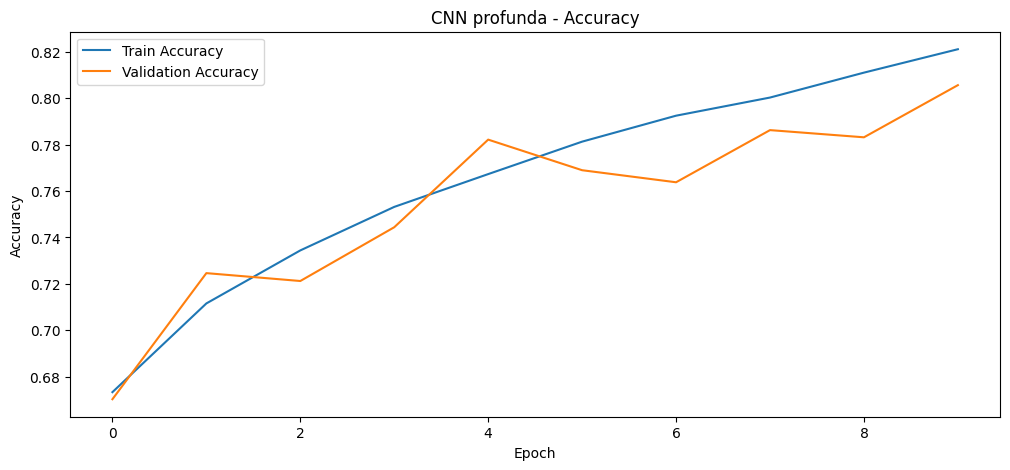

In [55]:
plt.figure(figsize=(12,5))

plt.plot(
    history_deep_cnn.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_deep_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN profunda - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [ ]:
Señal de overfitting
Si ocurre:
train accuracy sigue subiendo mucho,
validation accuracy se estanca,
entonces aparece sobreajuste.
Pero en vuestra arquitectura:
BatchNorm
Dropout
deberían mitigarlo bastante.

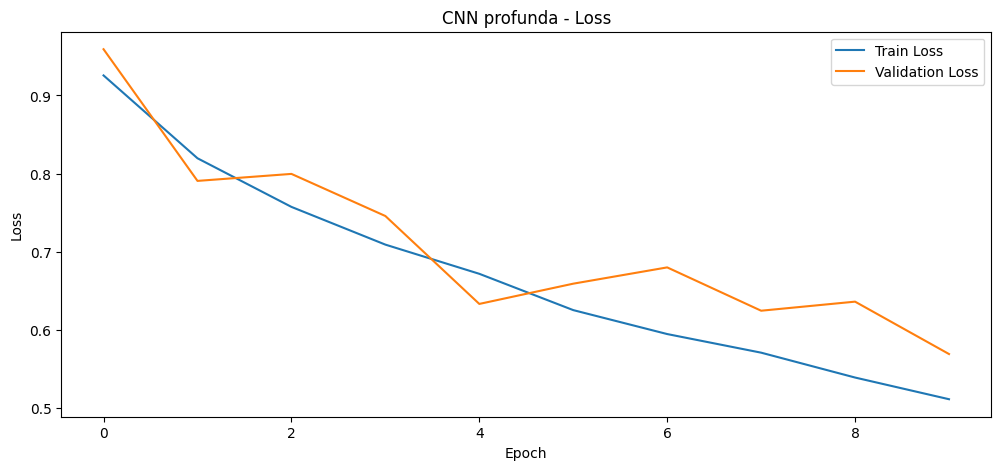

In [56]:
plt.figure(figsize=(12,5))

plt.plot(
    history_deep_cnn.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_deep_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN profunda - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [57]:
test_loss_deep, test_accuracy_deep = model_deep_cnn.evaluate(
    x_test,
    y_test_one_hot
)

print(f"Test accuracy: {test_accuracy_deep:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8081 - loss: 0.5715
Test accuracy: 0.8081


In [ ]:
La CNN profunda logra un rendimiento superior respecto a arquitecturas anteriores gracias a su mayor capacidad para aprender representaciones jerárquicas complejas. La incorporación de múltiples bloques convolucionales permite capturar patrones visuales de alto nivel, mientras que las técnicas de regularización ayudan a mantener una buena capacidad de generalización.

In [59]:
y_pred_deep = model_deep_cnn.predict(x_test)

y_pred_classes_deep = np.argmax(y_pred_deep, axis=1)

y_true = np.argmax(y_test_one_hot, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [62]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes_deep,
    target_names=MAP_ELEMENTS.values()
))

              precision    recall  f1-score   support

       avion       0.85      0.81      0.83      1000
       coche       0.92      0.90      0.91      1000
         ave       0.83      0.67      0.74      1000
        gato       0.70      0.57      0.63      1000
      ciervo       0.75      0.81      0.78      1000
       perro       0.70      0.76      0.73      1000
        rana       0.74      0.93      0.82      1000
     caballo       0.86      0.82      0.84      1000
       barco       0.88      0.92      0.90      1000
      camion       0.88      0.90      0.89      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



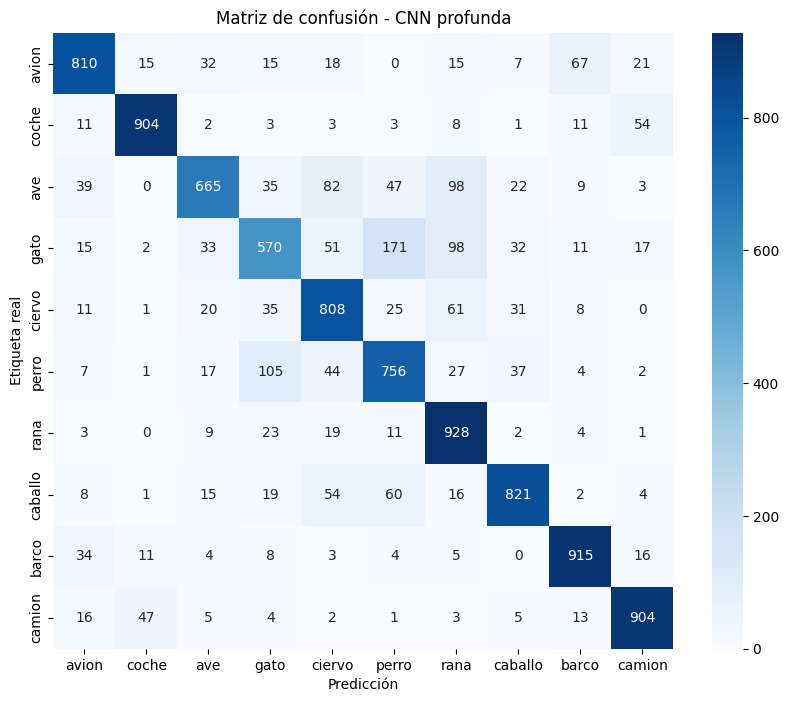

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_deep = confusion_matrix(
    y_true,
    y_pred_classes_deep
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_deep,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=MAP_ELEMENTS.values(),
    yticklabels=MAP_ELEMENTS.values()
)

plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')

plt.title('Matriz de confusión - CNN profunda')

plt.show()

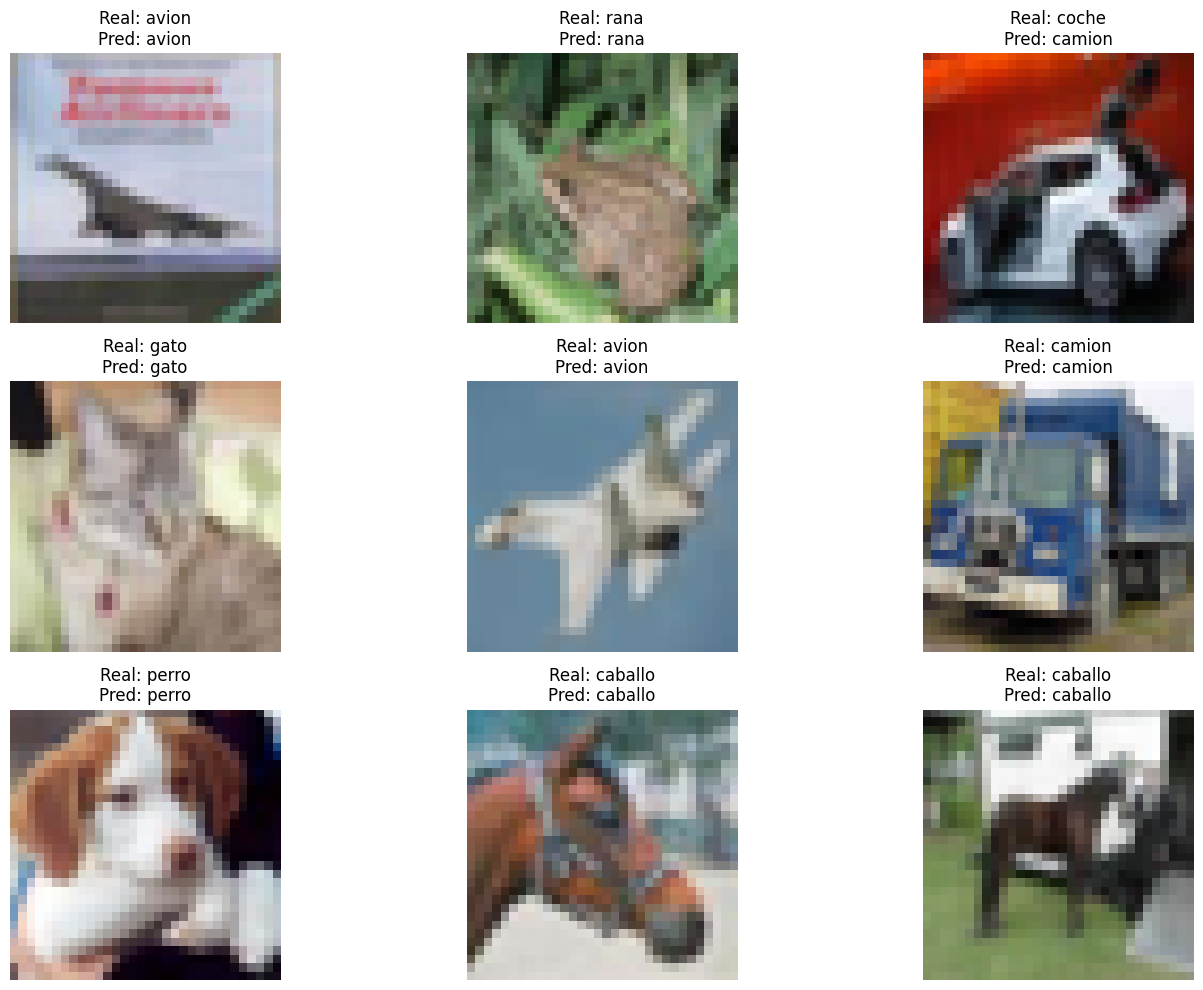

In [64]:
plt.figure(figsize=(15,10))

for i, idx in enumerate(errors[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(x_test[idx])

    plt.title(
        f"Real: {MAP_ELEMENTS[y_true[idx]]}\n"
        f"Pred: {MAP_ELEMENTS[y_pred_classes_deep[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

## **6. Data augmentation**

In [ ]:
Data augmentation mejora la capacidad de generalización al exponer al modelo a variaciones artificiales de los datos de entrenamiento, permitiendo aprender representaciones más invariantes y robustas frente a transformaciones visuales.

In [ ]:
rotation_range=15
Permite rotaciones aleatorias hasta ±15 grados.
Objetivo:
robustez frente a pequeñas rotaciones,
evitar dependencia de orientación exacta.
width_shift_range=0.1
Desplaza horizontalmente hasta el 10% de la imagen.
Objetivo:
aprender invariancia espacial,
evitar dependencia de posición exacta.
height_shift_range=0.1
Desplazamiento vertical aleatorio.
Misma idea:
robustez frente a traslaciones
horizontal_flip=True
Invierte imágenes horizontalmente aleatoriamente.
Muy útil en CIFAR-10 porque:
un coche sigue siendo un coche invertido,
un avión sigue siendo un avión.

In [ ]:
El Data Augmentation introduce transformaciones aleatorias sobre las imágenes de entrenamiento con el objetivo de aumentar artificialmente la diversidad del dataset. Esto permite que el modelo aprenda representaciones más robustas e invariantes frente a pequeñas variaciones espaciales y geométricas.

In [69]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)


In [ ]:
Antes del entrenamiento podéis mostrar ejemplos aumentados.


In [ ]:
plt.figure(figsize=(10,10))

for images, labels in datagen.flow(
    x_train,
    y_train_one_hot,
    batch_size=9
):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.axis('off')

    plt.tight_layout()

    break

plt.show()

In [ ]:
Data augmentation no mejora el rendimiento porque el modelo “memorice más”, sino porque aprende representaciones más robustas frente a variaciones visuales.

In [68]:
history_aug = model_deep_cnn.fit(

    datagen.flow(
        x_train,
        y_train_one_hot,
        batch_size=64
    ),

    epochs=10,

    validation_data=(
        x_valid,
        y_valid_one_hot
    )
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.7374 - loss: 0.7485 - val_accuracy: 0.7506 - val_loss: 0.7602
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.7526 - loss: 0.7108 - val_accuracy: 0.7567 - val_loss: 0.7439
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.7577 - loss: 0.6959 - val_accuracy: 0.7699 - val_loss: 0.6639
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7625 - loss: 0.6824 - val_accuracy: 0.7941 - val_loss: 0.6019
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.7695 - loss: 0.6672 - val_accuracy: 0.7761 - val_loss: 0.6608
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7738 - loss: 0.6528 - val_accuracy: 0.7751 - val_loss: 0.6603
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7799 - loss: 0.6410 - val_accuracy: 0.8075 - val_loss: 0.5527
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7791 - loss: 0.6349 - 

In [ ]:
La incorporación de Data Augmentation incrementó la variabilidad del conjunto de entrenamiento mediante transformaciones aleatorias aplicadas sobre las imágenes. Esto dificultó la memorización de ejemplos específicos y favoreció el aprendizaje de representaciones más robustas e invariantes.
Aunque la accuracy de entrenamiento resultó ligeramente inferior, el modelo obtuvo una mejor accuracy de validación y un comportamiento más estable, evidenciando una mejora en la capacidad de generalización y una reducción del sobreajuste.

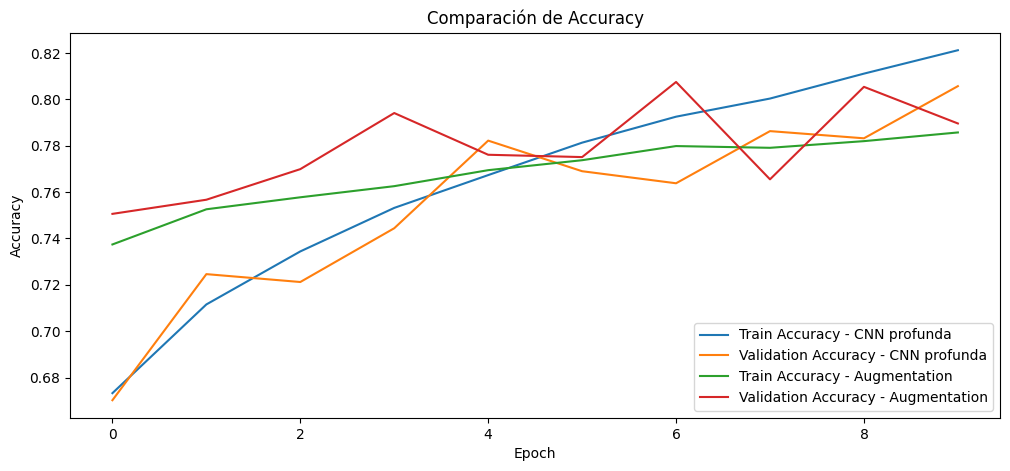

In [70]:
plt.figure(figsize=(12,5))

# CNN profunda sin augmentation
plt.plot(
    history_deep_cnn.history['accuracy'],
    label='Train Accuracy - CNN profunda'
)

plt.plot(
    history_deep_cnn.history['val_accuracy'],
    label='Validation Accuracy - CNN profunda'
)

# CNN con augmentation
plt.plot(
    history_aug.history['accuracy'],
    label='Train Accuracy - Augmentation'
)

plt.plot(
    history_aug.history['val_accuracy'],
    label='Validation Accuracy - Augmentation'
)

plt.title('Comparación de Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

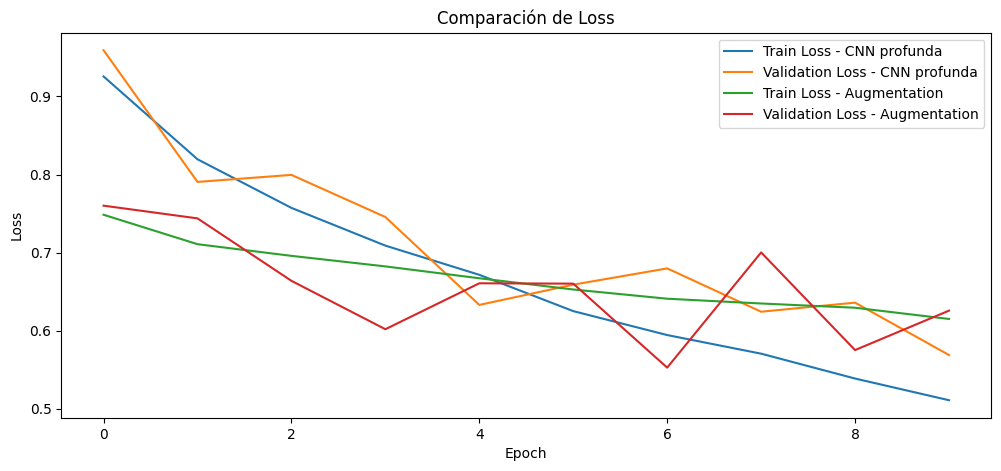

In [71]:
plt.figure(figsize=(12,5))

# CNN profunda sin augmentation
plt.plot(
    history_deep_cnn.history['loss'],
    label='Train Loss - CNN profunda'
)

plt.plot(
    history_deep_cnn.history['val_loss'],
    label='Validation Loss - CNN profunda'
)

# CNN con augmentation
plt.plot(
    history_aug.history['loss'],
    label='Train Loss - Augmentation'
)

plt.plot(
    history_aug.history['val_loss'],
    label='Validation Loss - Augmentation'
)

plt.title('Comparación de Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

## **7. Evaluación final y análisis de errores**

## **8. Conclusiones finales**